In [20]:
# Q1, Part 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df


df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

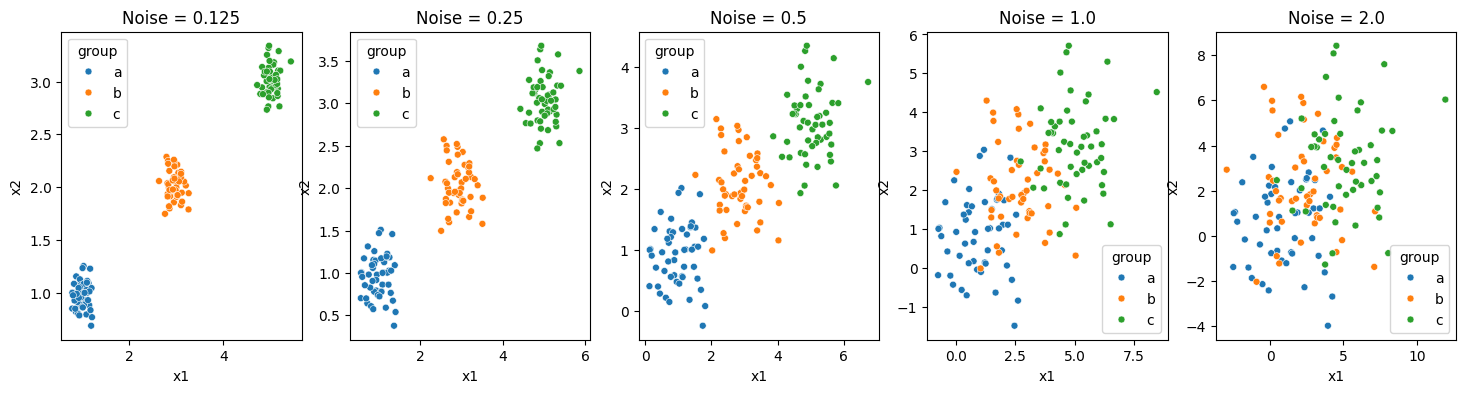

In [21]:
# Q1, Part 2
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes = axes.ravel()

sns.scatterplot(data=df0_125, x='x1', y='x2', hue='group', ax=axes[0], s=25)
axes[0].set_title("Noise = 0.125")

sns.scatterplot(data=df0_25, x='x1', y='x2', hue='group', ax=axes[1], s=25)
axes[1].set_title("Noise = 0.25")

sns.scatterplot(data=df0_5, x='x1', y='x2', hue='group', ax=axes[2], s=25)
axes[2].set_title("Noise = 0.5")

sns.scatterplot(data=df1_0, x='x1', y='x2', hue='group', ax=axes[3], s=25)
axes[3].set_title("Noise = 1.0")

sns.scatterplot(data=df2_0, x='x1', y='x2', hue='group', ax=axes[4], s=25)
axes[4].set_title("Noise = 2.0")

plt.show()

# As we go up from 0.125 to 2.0, we see that the visual clusters get more and more spread out. The groups starts to become much more integrated towards 2.0. 


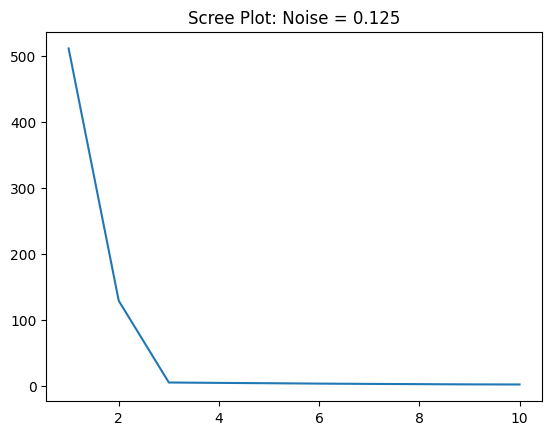

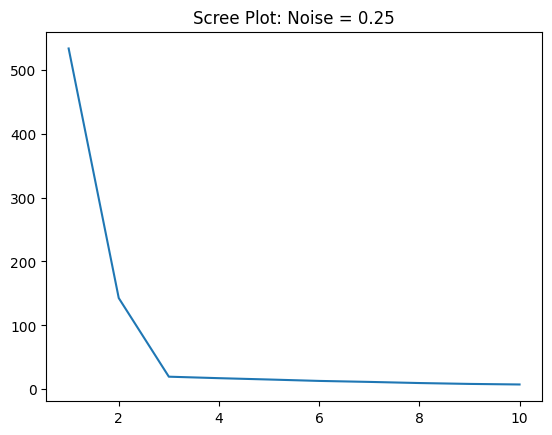

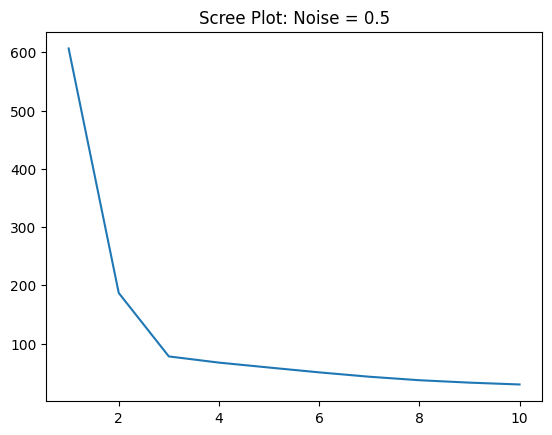

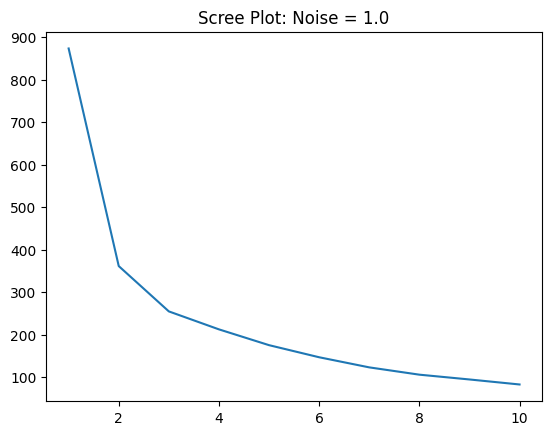

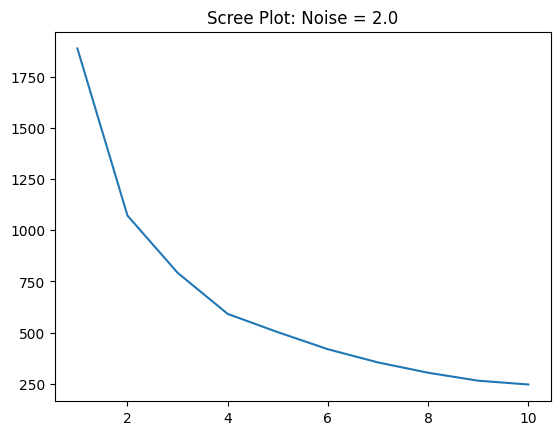

In [22]:
#Q1, Part 3

k_bar = 10
SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(df0_125[['x1','x2']])
    SSE.append(model.inertia_)
sns.lineplot(x=np.arange(1, k_bar+1), y=SSE).set_title('Scree Plot: Noise = 0.125')
plt.show()

SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(df0_25[['x1','x2']])
    SSE.append(model.inertia_)
sns.lineplot(x=np.arange(1, k_bar+1), y=SSE).set_title('Scree Plot: Noise = 0.25')
plt.show()

SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(df0_5[['x1','x2']])
    SSE.append(model.inertia_)
sns.lineplot(x=np.arange(1, k_bar+1), y=SSE).set_title('Scree Plot: Noise = 0.5')
plt.show()

SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(df1_0[['x1','x2']])
    SSE.append(model.inertia_)
sns.lineplot(x=np.arange(1, k_bar+1), y=SSE).set_title('Scree Plot: Noise = 1.0')
plt.show()

SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(df2_0[['x1','x2']])
    SSE.append(model.inertia_)
sns.lineplot(x=np.arange(1, k_bar+1), y=SSE).set_title('Scree Plot: Noise = 2.0')
plt.show()

# As the noise level increases, the clear elbow becomes less and less defined. This makes it mode difficult to select an ideal number of clusters, k. 

In [23]:
# Q1, Part 4

#Elbow method identifies the optimal number of clusters k by finding where adding more clusters stops reducing within-cluster variation. In this numerical example, the Low Noise (ex: 0.125) showed a clear ellbow in the scree plot and also reflected very well seperated clusters in the scatter plot. However, the high noise (ex:2.0) showed a smoother scree curve on the scree plot which showed that the clusters overlapped a lot more on the scatterplot which amde the k much harder to detect. 

In [ ]:
# Q2, Part 1

df = pd.read_csv('./data/2022 election cycle fundraising.csv')

print(df.shape)
print(df.columns.tolist())
df.head()

df['Raised'] = pd.to_numeric(df['Raised'].replace({r'\$': '', r',': '', r'\(': '-', r'\)': ''}, regex=True), errors='coerce')
df['Spent'] = pd.to_numeric(df['Spent'].replace({r'\$': '', r',': '', r'\(': '-', r'\)': ''}, regex=True), errors='coerce')
df['Cash on Hand'] = pd.to_numeric(df['Cash on Hand'].replace({r'\$': '', r',': '', r'\(': '-', r'\)': ''}, regex=True), errors='coerce')
df['Debts'] = pd.to_numeric(df['Debts'].replace({r'\$': '', r',': '', r'\(': '-', r'\)': ''}, regex=True), errors='coerce')

print(df[['Raised', 'Spent', 'Cash on Hand', 'Debts']].head())
print(df[['Raised', 'Spent', 'Cash on Hand', 'Debts']].isna().sum())


# I removed certain formatting characters such as "$ , ()" and converted the strings into a numeric character. Additionally, we changed the negative numbers that are in parenthesis into a -. Checked if there are any missing variables at the end and looked into the data afterwards to see the result. 

(537, 9)
['index', 'Member', 'Party', 'State', 'Chamber', 'Raised', 'Spent', 'Cash on Hand', 'Debts']
     Raised     Spent  Cash on Hand  Debts
0   7719396   7449678        851851      0
1   2192741   1243502       2472888      0
2  20993041  13957854      20942888      0
3   1211111   1173466        623472      0
4   1617611   1664674       1098579      0
Raised          0
Spent           0
Cash on Hand    0
Debts           0
dtype: int64


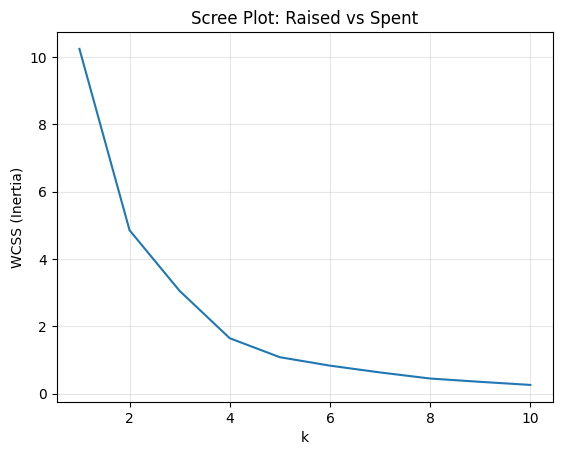

,Member,Raised,Spent,cluster
123,Darrell Issa,1115797,960887,7
133,David Trone,12990741,6878050,3
442,Ron Johnson,27680901,23731653,3
463,Sheila Cherfilus-McCormick,4250064,4276527,7


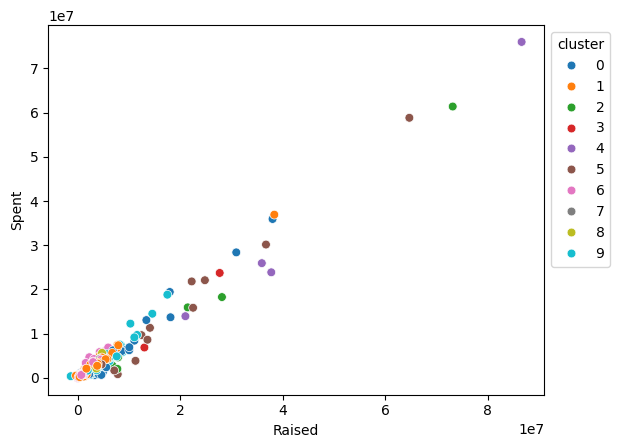

In [50]:
# Q2, Part 2

pair = ["Raised","Spent"]
df_rs = df.dropna(subset=pair).copy()

def maxmin(x): # Max-min scaler function
    x = (x-min(x))/(max(x)-min(x))
    return x

# Scree Plot
k_bar = 10
SSE = []
for k in range(k_bar):
   model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
   model = model.fit(X)
   SSE.append(model.inertia_)

scree_plot = sns.lineplot(x=np.arange(1, k_bar+1), y=SSE).set_title('Scree Plot: Raised vs Spent')
plt.xlabel("k")
plt.ylabel("WCSS (Inertia)")
plt.grid(alpha=0.3)
plt.show()

#Scatterplot
df['cluster'] = labels  
this_plot = sns.scatterplot(x='Raised', y='Spent', hue='cluster', data=df, s=40, palette='tab10')
sns.move_legend(this_plot, "upper left", bbox_to_anchor=(1, 1))

df['cluster'].value_counts()
small_clusters = df['cluster'].value_counts().sort_values().index[:2]
df[df['cluster'].isin(small_clusters)][['Member','Raised', 'Spent', 'cluster']]


# Based on the scree plot, the optimal cluster is when k = 3. The scatterplot shows there is a large cluster and then a couple of outliers. 

# Clusters 1 which includes Catherine Cortez Masto and Tim Ryan. Cluster 3 also has 2 politicians in it. Cluster 6 which includes Raphael Warnock. These are the politicians in the smallest two clusters. (I did not include Cluster 3 but there is also 2 politicians in this cluster)


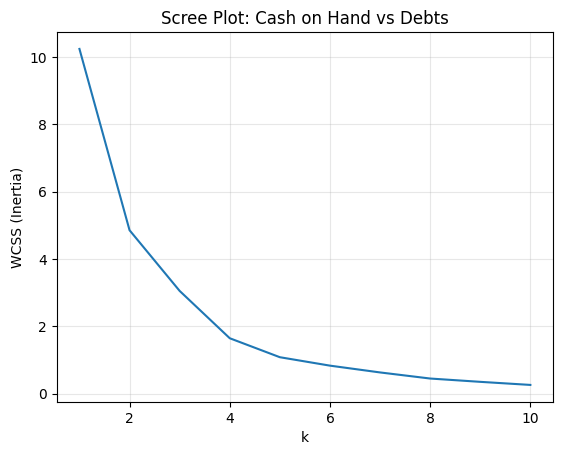

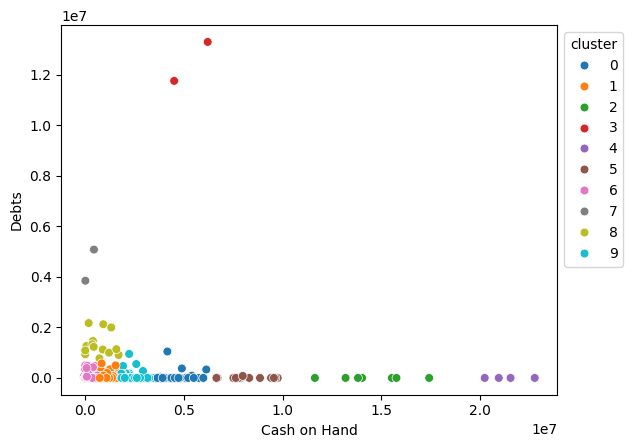

,Member,Cash on Hand,Debts,cluster
123,Darrell Issa,447473,5081387,7
133,David Trone,6206371,13302000,3
442,Ron Johnson,4508581,11759857,3
463,Sheila Cherfilus-McCormick,13498,3848131,7


In [ ]:
# Q2, Part 3

pair = ["Cash on Hand", "Debts"]
df_cd = df.dropna(subset=pair).copy()

def maxmin(x):  # Max-min scaler function
    x = (x - min(x)) / (max(x) - min(x))
    return x

X = df_cd[pair].apply(maxmin)

# Scree Plot
k_bar = 10
SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(X)
    SSE.append(model.inertia_)

scree_plot = sns.lineplot(x=np.arange(1, k_bar+1), y=SSE).set_title('Scree Plot: Cash on Hand vs Debts')
plt.xlabel("k")
plt.ylabel("WCSS (Inertia)")
plt.grid(alpha=0.3)
plt.show()

# Scatterplot
labels = model.labels_
df_cd['cluster'] = labels
this_plot = sns.scatterplot(x='Cash on Hand', y='Debts', hue='cluster', data=df_cd, s=40, palette='tab10')
sns.move_legend(this_plot, "upper left", bbox_to_anchor=(1, 1))
plt.show()

df_cd['cluster'].value_counts()
small_clusters = df_cd['cluster'].value_counts().sort_values().index[:2]
df_cd[df_cd['cluster'].isin(small_clusters)][['Member', 'Cash on Hand', 'Debts', 'cluster']]

# Both scree plots still show that the elbow is around 3-4. The scatterplot looks very different from the first scatterplot because they look at very different relationships. This scatterplot does not have a clear trend and there are no clear patterns. 
# This graph shows financial debt and burden. We can see that many of the politicians have low or no debt. 
# The smallest clusters are Cluster 3 and 7. The politicans that are in this group are Darrell Issa and Sheila CHerfilius-McCormick. For Cluster 3, David Trone and Ron Johnson. 


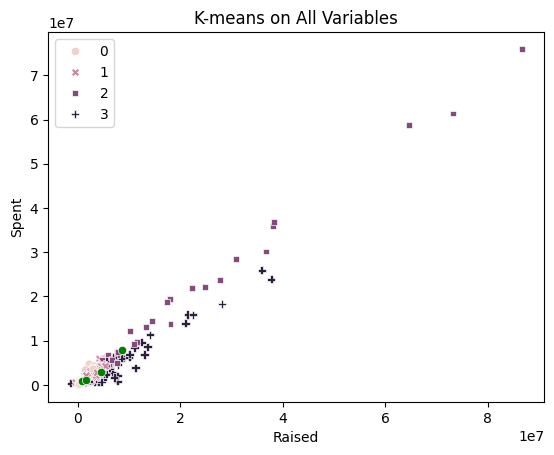

In [70]:
# Q2, Part 4
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


money_cols = ['Raised', 'Spent', 'Cash on Hand', 'Debts']
df_all = df.dropna(subset=money_cols).copy()

def maxmin(x):
    return (x - x.min()) / (x.max() - x.min())

X = df_all[money_cols].apply(maxmin)


x_var = 'Raised'
y_var = 'Spent'
x_orig = df_all[x_var]
y_orig = df_all[y_var]
min_x, max_x = x_orig.min(), x_orig.max()
min_y, max_y = y_orig.min(), y_orig.max()


np.random.seed(10)
initial_centroids = np.random.randint(low=0, high=X.shape[0], size=4)
model = KMeans(
    n_clusters=4,
    max_iter=1,
    init=X.iloc[initial_centroids, :],
    n_init=1,
    random_state=0
)
model = model.fit(X)
df_all['g_hat'] = model.predict(X)

centers = model.cluster_centers_
centroid_x = centers[:, money_cols.index(x_var)] * (max_x - min_x) + min_x
centroid_y = centers[:, money_cols.index(y_var)] * (max_y - min_y) + min_y

this_plot = sns.scatterplot(
    data=df_all,
    x=x_var,
    y=y_var,
    hue='g_hat',
    style='g_hat'
)
this_plot.set_title('K-means on All Variables')
sns.scatterplot(x=centroid_x, y=centroid_y, color='green')
plt.show()

# Similar to Raised v Spent but there are many more outliers. This is also the case because the dimensions are similar to Question 3. Very different looking than Question 4


In [ ]:
#Q2, Part 5

# Yes, it wa helpful in finding patterns of outliers. It gave us results based on fundraising/spending and those who were udner financial stress. This helps with finding conclusions in real world campaigns and finding which ones are making profit and which ones are sinking in debt. 